<a href="https://colab.research.google.com/github/Rouba-Os/AI-Course/blob/main/Assignment8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install -y git
!git config --global user.email "rouba.osko@students.williscollege.com"
!git config --global user.name "Rouba-Os"

print("Git configured successfully")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Git configured successfully


In [2]:
!git clone https://github.com/Rouba-Os/AI-Course.git
%cd AI-Course
!ls

Cloning into 'AI-Course'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 39 (delta 19), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 319.17 KiB | 5.70 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/AI-Course
AICourse.ipynb	   Assignment5.ipynb  git_github_exercise.ipynb
assignment2.ipynb  Assignment6.ipynb  README.md
Assignment3.ipynb  Assignment7.ipynb


In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
# Improt Librarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import joblib

sns.set()

In [5]:
# Load Dataset
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# Quick Check of Data

print('Data first few rows\n', df.head())

print('\nData info\n', df.info())

print('\nData Statistical summary\n', df.describe())



Data first few rows
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   su

In [7]:
# EDA and Data Preprocessing
## Check for missing/null values
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [11]:
# EDA and Data Preprocessing
## Handle/fill missing values
df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

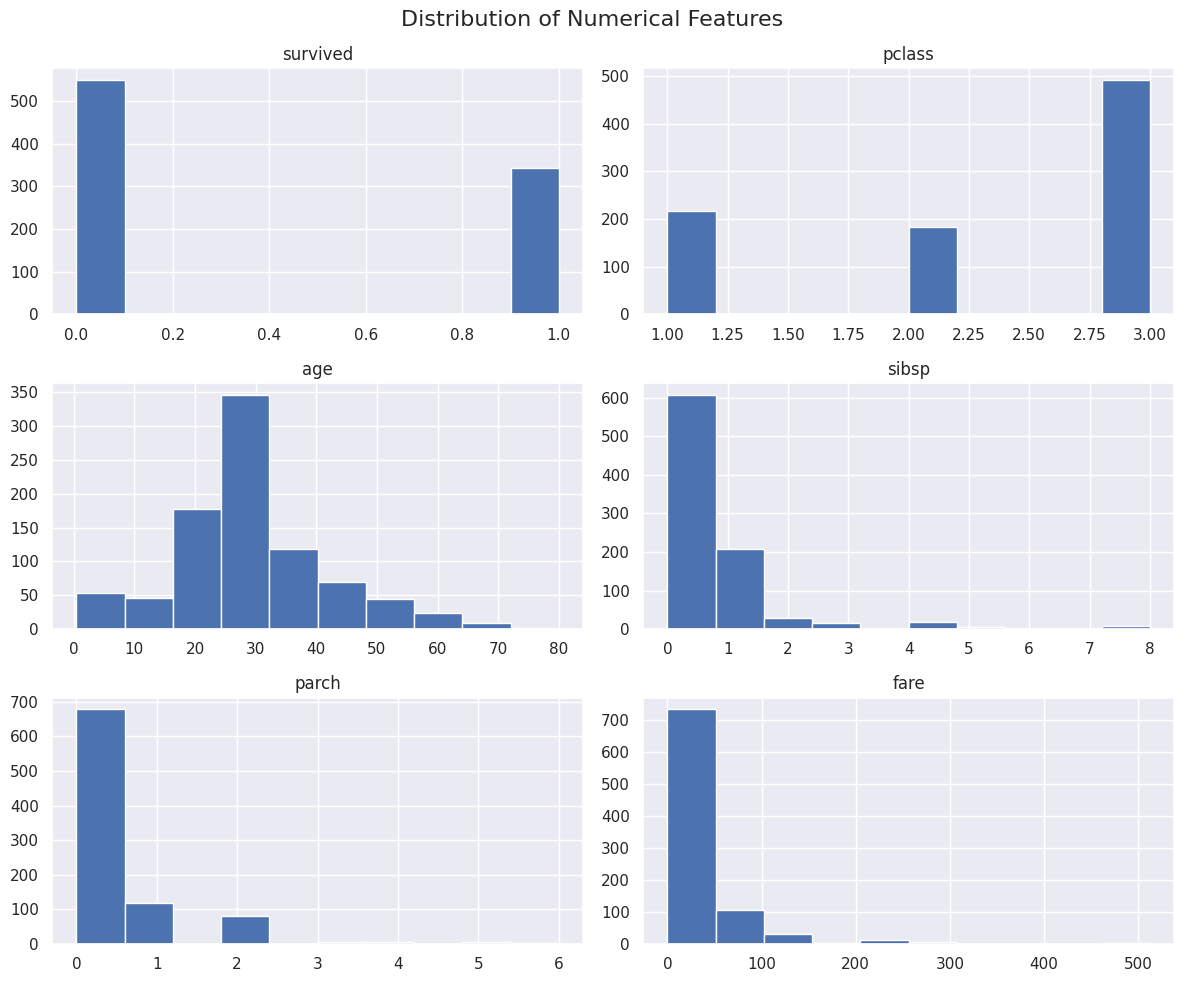

In [12]:
# EDA and Data Preprocessing
## Distribution of Numerical Features
df.hist(figsize=(12,10))
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

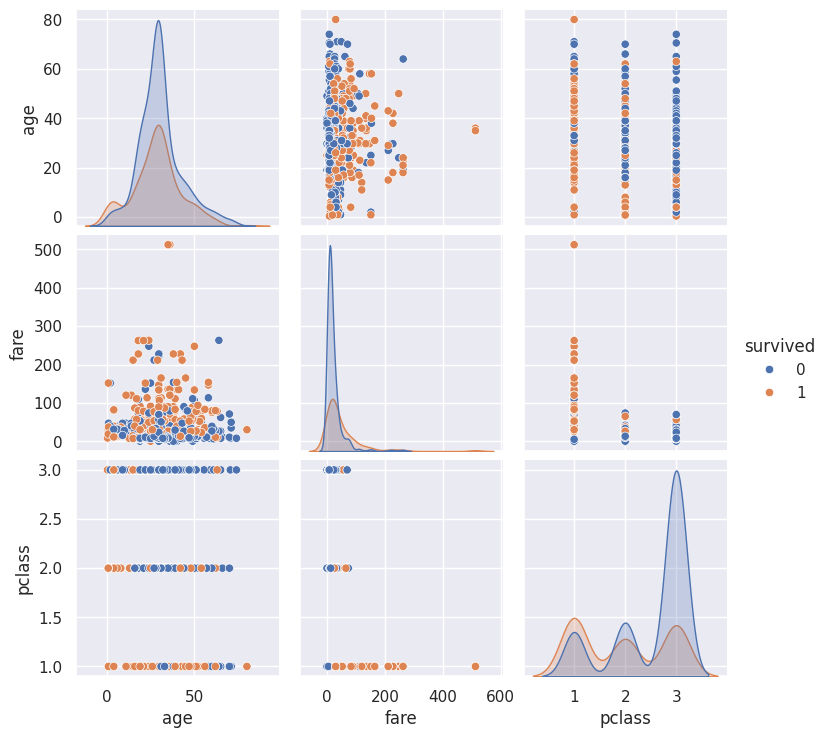

In [13]:
# EDA and Data Preprocessing
## Pair plot
sns.pairplot(df[["age","fare","pclass","survived"]], hue="survived")

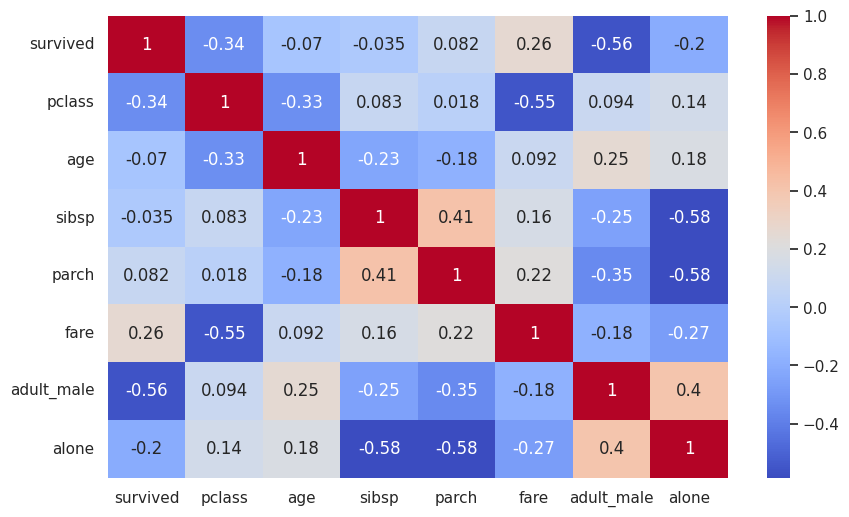

In [14]:
# EDA and Data Preprocessing
## Correlation analysis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [15]:
# Data Preprocessing
## Encoding categorial data
label = LabelEncoder()

df["sex"] = label.fit_transform(df["sex"])
df["embarked"] = label.fit_transform(df["embarked"].astype(str))

In [16]:
## Feature selection
X = df[["pclass", "sex", "age", "fare", "embarked"]]
y = df["survived"]

In [17]:
# Data Preprocessing
## Feature scaling (Normalization)
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [18]:
# Data Preprocessing
## Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# Model 1: Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [20]:
# Model 1 evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.770949720670391
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       110
           1       0.72      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



In [21]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [22]:
# Model 2 evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



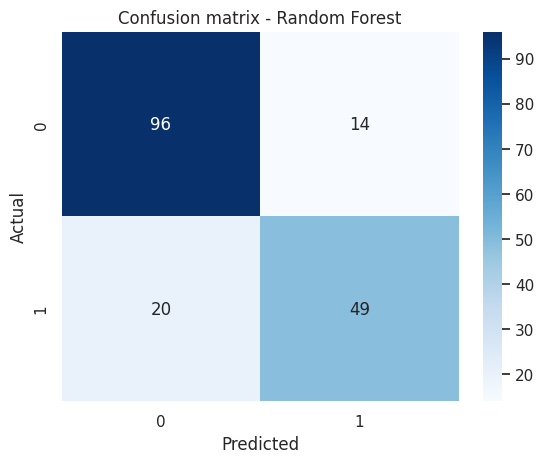

In [24]:
# Confusion Matrix
cnf_matrix = confusion_matrix(y_test, y_pred_rf)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="Blues" ,fmt='g')
plt.title('Confusion matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

FPR
[0.         0.00909091 0.00909091 0.00909091 0.01818182 0.01818182
 0.01818182 0.01818182 0.01818182 0.01818182 0.02727273 0.02727273
 0.03636364 0.03636364 0.05454545 0.05454545 0.06363636 0.06363636
 0.07272727 0.07272727 0.08181818 0.08181818 0.08181818 0.08181818
 0.09090909 0.09090909 0.1        0.1        0.11818182 0.11818182
 0.12727273 0.12727273 0.13636364 0.13636364 0.18181818 0.18181818
 0.2        0.2        0.22727273 0.24545455 0.24545455 0.25454545
 0.31818182 0.32727273 0.33636364 0.34545455 0.34545455 0.36363636
 0.38181818 0.39090909 0.40909091 0.43636364 0.43636364 0.50909091
 0.54545455 0.55454545 0.56363636 0.59090909 0.60909091 0.62727273
 0.62727273 0.65454545 0.68181818 0.70909091 0.71818182 0.74545455
 0.75454545 0.8        0.80909091 0.86363636 0.89090909 0.9
 1.        ]
TPR
[0.         0.04347826 0.07246377 0.13043478 0.13043478 0.1884058
 0.23188406 0.24637681 0.27536232 0.30434783 0.30434783 0.31884058
 0.31884058 0.34782609 0.4057971  0.42028986 0.42

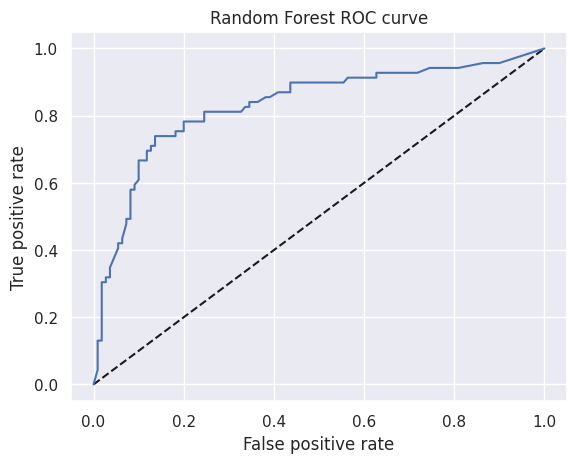

AUC Score: 0.830764163372859


In [28]:
# ROC Curve and AUC
## Predict probabilities
y_pred_proba = rf.predict_proba(X_test)[:,1]

## Get FPR, TPR, Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

print("FPR")
print(fpr)

print("TPR")
print(tpr)

print("Thresholds")
print(thresholds)

## ROC curve
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr, label='Random Forest')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Random Forest ROC curve')
plt.show()

## AUC score
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

In [29]:
# Model Comparison
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.770949720670391
Random Forest Accuracy: 0.8100558659217877


In [31]:
# Model Saving
joblib.dump(rf, "titanic_model.pkl")

['titanic_model.pkl']

In [32]:
# Model Saving
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [34]:
!git add scaler.pkl titanic_model.pkl
!git commit -m "Add trained model and scaler"

[main 60136dc] Add trained model and scaler
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 scaler.pkl
 create mode 100644 titanic_model.pkl


In [35]:
!git add *.ipynb README.md scaler.pkl titanic_model.pkl
!git commit -m "Add all assignment related code files including notebooks and model artifacts"

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
